# **Problem Statment:**

Dataset: Web Traffic Time Series Forecasting

Forecasting the future values of multiple time series. More specifically the problem of forecasting future web traffic for approximately 145,000 articles on britanica.

The training dataset consists of approximately 145k time series. Each of these time series represent a number of daily views of a different article, starting from July, 1st, 2015 up until December 31st, 2016. For each time series, you are provided the name of the article as well as the type of traffic that this time series represent (all, mobile, desktop, spider). You may use this metadata and any other publicly available data to make predictions. Unfortunately, the data source for this dataset does not distinguish between traffic values of zero and missing values. A missing value may mean the traffic was zero or that the data is not available for that day.

**Data Dictionary:**

There are two csv files given

*train_1.csv : *

In the csv file, each row corresponds to a particular article and each column correspond to a particular date. The values are the number of visits in that date.

*Exog_Campaign_eng : *

This file contains data for the dates which had a campaign or significant event that could affect the views for that day. the data is just for pages in english.

There is a 1 for dates with campaign and 0 for remaining dates. It is to be treated as an exogenous variable for models when training and forecasting data for pages in english

**Intent of the notebook**
We will start by loading the data and handling the values.

Then some Exploratory data analysis to get an understanding of the data and get some useful insight, based on various parameters, and visualizing them.

Preparing the data for feeding to the model(checking stationarity, transformations).

Preparing the model followed by some predictions.

Comparing the same with the given data and calculating the accuracy of the model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
train=pd.read_csv('train_1.csv')
train.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [ ]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB


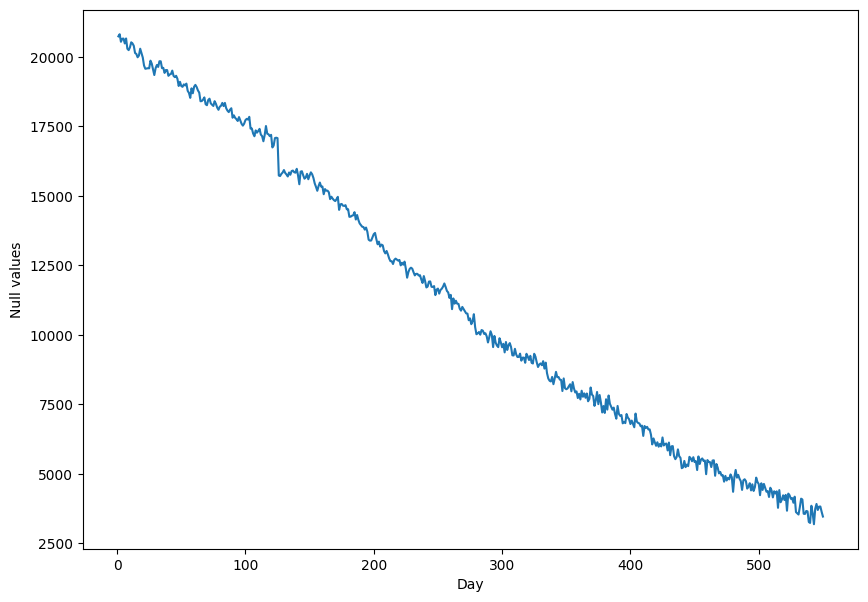

In [ ]:
days = [r for r in range(1, len(train.columns))]
plt.figure(figsize=(10,7))
plt.xlabel('Day')
plt.ylabel('Null values')
plt.plot(days, train.isnull().sum()[1:])

We see that the number of nan values decrease with time.

Probable reason: Some website have all nan values in the begining, that can be due to the fact that those were created after that time so there is no traffic reading for that time

In [ ]:
train=train.fillna(0)
train.tail()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
145058,Underworld_(serie_de_películas)_es.wikipedia.o...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,13.0,12.0,13.0,3.0,5.0,10.0
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-acc...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145061,Hasta_el_último_hombre_es.wikipedia.org_all-ac...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145062,Francisco_el_matemático_(serie_de_televisión_d...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The page values are in this format

SPECIFIC NAME _ LANGUAGE.britanica.org _ ACCESS TYPE _ ACCESS ORIGIN

Having information about page name, the main domain, device type used to access the page, and also the request origin(spider or browser agent)

In [ ]:
import re
#Usage of Regex
def split_page(page):
    w = re.split('_|\.', page)
    print(w)
    return ' '.join(w[:-5]), w[-5], w[-2], w[-1]

split_page('2NE1_zh.britanica.org_all-access_spider')


['2NE1', 'zh', 'britanica', 'org', 'all-access', 'spider']


('2NE1', 'zh', 'all-access', 'spider')

In [ ]:
def split_page(page):
  w = re.split('_|\.', page)
  return ' '.join(w[:-5]), w[-5], w[-2], w[-1]

li = list(train.Page.apply(lambda x: split_page(str(x))))
df = pd.DataFrame(li)
df.columns = ['Title', 'Language', 'Access_type','Access_origin']
df = pd.concat([train, df], axis = 1)

In [ ]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,Title,Language,Access_type,Access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,4minute,zh,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,11.0,27.0,13.0,36.0,10.0,52 Hz I Love You,zh,all-access,spider


<Axes: xlabel='Language', ylabel='count'>

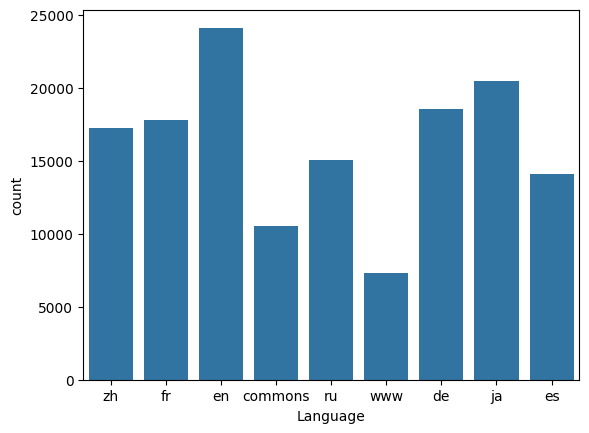

In [ ]:
sns.countplot(x=df['Language'])

Moving commons and www values

In [ ]:
# extracting language
def Extract_Language(name):
  if len(re.findall(r'_(.{2}).wikipedia.org_', name)) == 1 :
    return re.findall(r'_(.{2}).wikipedia.org_', name)[0]
  else:
    return 'no_lang'




<Axes: xlabel='Language', ylabel='count'>

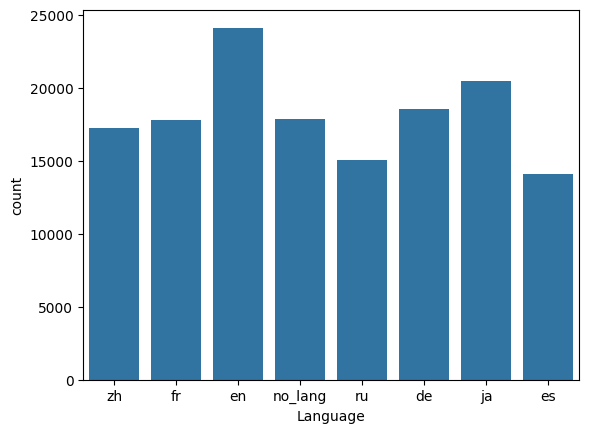

In [ ]:
df['Language']=df["Page"].map(Extract_Language)
sns.countplot(x=df['Language'])

This above is the comparision number of articles in each language

{'ja':'Japanese', 'de':'German', 'en' : 'English', 'no_lang':'Media_File', 'fr':'French', 'zh':'Chinese', 'ru':'Russian', 'es':'Spanish'}

<Axes: xlabel='Access_type', ylabel='count'>

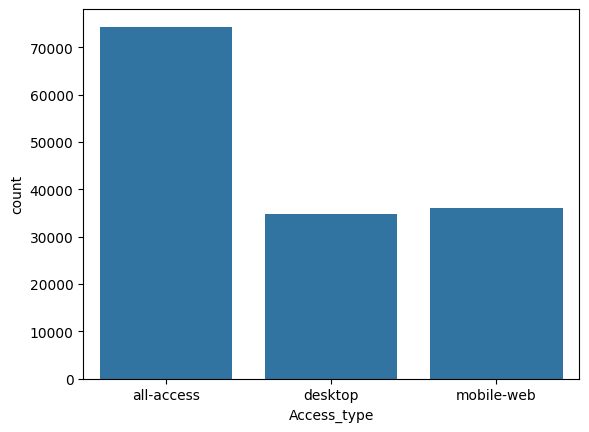

In [ ]:
sns.countplot(x=df['Access_type'])

A spider is a computer program, also known as a web crawler or bot, that systematically browses the internet and collects information from websites. Search engines like Google and Bing use spiders to index web pages and gather data so that websites can appear in search engine results.
Spiders work by visiting websites, reading their pages, and other information to create entries for a search engine index.

<Axes: xlabel='Access_origin', ylabel='count'>

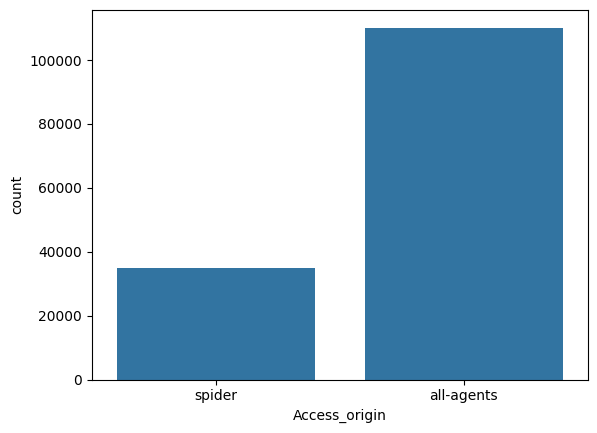

In [ ]:
sns.countplot(x=df['Access_origin'])

This shows that not much data is from spiders or bots

Compare views of pages in different languages

In [ ]:
df.groupby('Language').count()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,Title,Access_type,Access_origin
Language,,,,,,,,,,,,,,,,,,,,,
de,18547,18547,18547,18547,18547,18547,18547,18547,18547,18547,...,18547,18547,18547,18547,18547,18547,18547,18547,18547,18547
en,24108,24108,24108,24108,24108,24108,24108,24108,24108,24108,...,24108,24108,24108,24108,24108,24108,24108,24108,24108,24108
es,14069,14069,14069,14069,14069,14069,14069,14069,14069,14069,...,14069,14069,14069,14069,14069,14069,14069,14069,14069,14069
fr,17802,17802,17802,17802,17802,17802,17802,17802,17802,17802,...,17802,17802,17802,17802,17802,17802,17802,17802,17802,17802
ja,20431,20431,20431,20431,20431,20431,20431,20431,20431,20431,...,20431,20431,20431,20431,20431,20431,20431,20431,20431,20431
no_lang,17855,17855,17855,17855,17855,17855,17855,17855,17855,17855,...,17855,17855,17855,17855,17855,17855,17855,17855,17855,17855
ru,15022,15022,15022,15022,15022,15022,15022,15022,15022,15022,...,15022,15022,15022,15022,15022,15022,15022,15022,15022,15022
zh,17229,17229,17229,17229,17229,17229,17229,17229,17229,17229,...,17229,17229,17229,17229,17229,17229,17229,17229,17229,17229


In [ ]:
df_numeric = df.select_dtypes(include=['number'])
df_language = df_numeric.groupby(df['Language']).mean().transpose()


In [ ]:
df_language.head()

Language,de,en,es,fr,ja,no_lang,ru,zh
2015-07-01,714.968405,3513.862203,1085.972919,475.150994,580.647056,83.479922,629.999601,240.582042
2015-07-02,705.229741,3502.511407,1037.814557,478.202000,666.672801,87.471857,640.902876,240.941958
2015-07-03,676.877231,3325.357889,954.412680,459.837659,602.289805,82.680538,594.026295,239.344071
2015-07-04,621.145145,3462.054256,896.050750,491.508932,756.509177,70.572557,558.728132,241.653491
2015-07-05,722.076185,3575.520035,974.508210,482.557746,725.720914,78.214562,595.029157,257.779674


In [ ]:
df_language.reset_index(inplace=True)
df_language.set_index('index', inplace=True)

Text(0, 0.5, 'Views per Page')

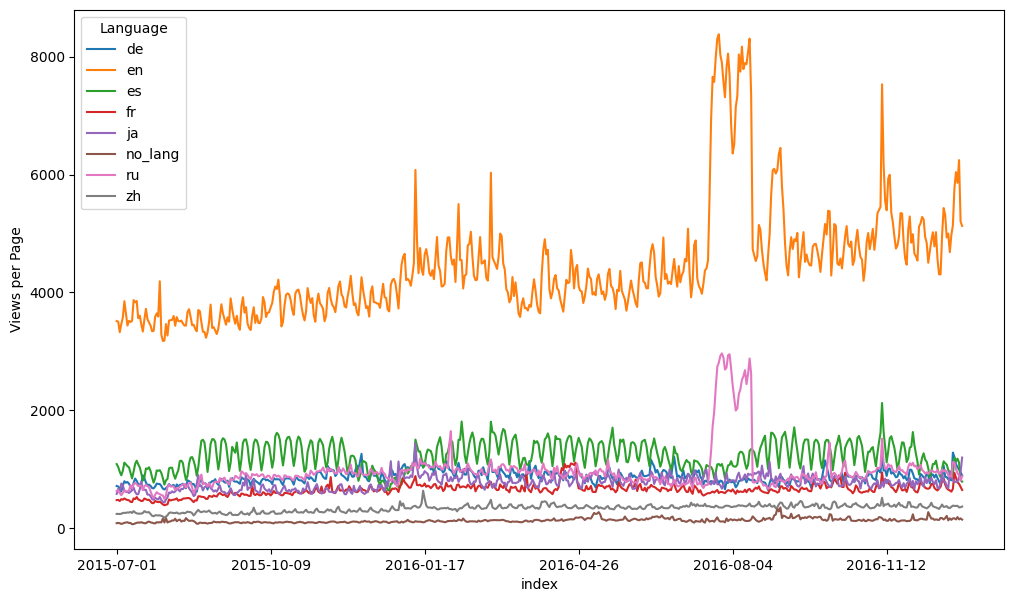

In [ ]:
df_language.plot(figsize=(12,7))
plt.ylabel('Views per Page')

Ploting the data shows that articles in english get the most number of views as compared to different languages, there are some spikes at different times in different laguages

As per plot, english language is most visited language w.r.t time index. In month of July to
September it is in peak.

Text(0, 0.5, 'Views per Page')

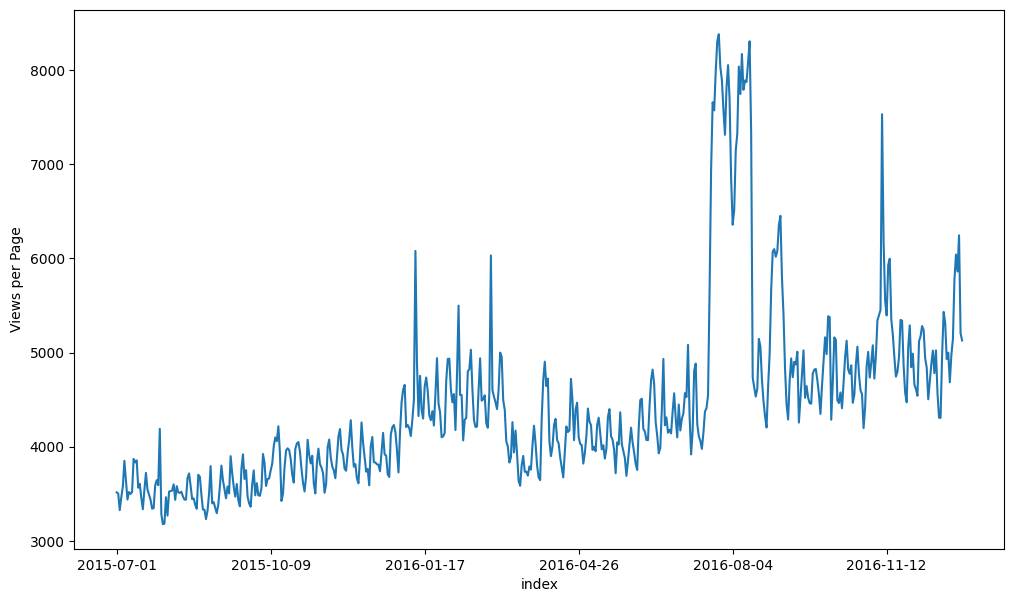

In [ ]:
df_language['en'].plot(figsize=(12,7))
plt.ylabel('Views per Page')

**Hypothesis Testing :** To check if Time Series is
Stationary or Trending :

**Null Hypothesis: ** The series is Non-Stationary
*Alternative Hypothesis: *The series is Stationary
*significant value :* 0.05 (alpha)
*if p-value > 0.05 :* we failed to reject Null hypothesis: In [ ]: In [41]:
plt.rcParams['figure.figsize'] = (20, 15)
aggregated_data.plot()
plt.xlabel("Time Index")
plt.ylabel("Visits Per Each Language")
plt.show()
5/16/24, 11:15 AM ad-ease
localhost:8888/nbconvert/html/Scaler/Projects/ad-ease.ipynb?download=false 12/34
That means the series is Non-Stationary if p-value <= 0.05: we reject Null Hypothesis
that means the time series in Stationary

In [ ]:
import statsmodels.api as sm
def Dickey_Fuller_test(ts,significances_level = 0.05):
 p_value = sm.tsa.stattools.adfuller(ts)[1]
 if p_value <= significances_level:
  print("Time Series is Stationary")
 else:
  print("Time Series is NOT Stationary")
 print("P_value is: ", p_value)

In [ ]:
for Language in df_language.columns:
 print(Language)
 print(Dickey_Fuller_test(df_language[Language],significances_level = 0.05))
 print()
 print()

de
Time Series is NOT Stationary
P_value is:  0.14097382319729534
None


en
Time Series is NOT Stationary
P_value is:  0.18953359279992404
None


es
Time Series is Stationary
P_value is:  0.033588590844791
None


fr
Time Series is NOT Stationary
P_value is:  0.05149502195245795
None


ja
Time Series is NOT Stationary
P_value is:  0.10257133898557641
None


no_lang
Time Series is Stationary
P_value is:  0.016293558379490952
None


ru
Time Series is Stationary
P_value is:  0.0018649376536617886
None


zh
Time Series is NOT Stationary
P_value is:  0.4474457922931142
None




* Based on DickeyFuller test of Stationarity , we can observe Spanish and Russian languages Pages visits Time series are stationary.
* Chinese, English , German , Japanese and French are not stationary

**Making the time series stationary**

In [ ]:
ts=df_language['en']
ts

,en
index,
2015-07-01,3513.862203
2015-07-02,3502.511407
2015-07-03,3325.357889
2015-07-04,3462.054256
2015-07-05,3575.520035
...,...
2016-12-27,6040.680728
2016-12-28,5860.227559
2016-12-29,6245.127510


In [ ]:
ts.index = pd.to_datetime(ts.index)  # Ensure the index is DatetimeIndex

#ts.set_index('index', inplace=True)
ts

,en
index,
2015-07-01,3513.862203
2015-07-02,3502.511407
2015-07-03,3325.357889
2015-07-04,3462.054256
2015-07-05,3575.520035
...,...
2016-12-27,6040.680728
2016-12-28,5860.227559
2016-12-29,6245.127510


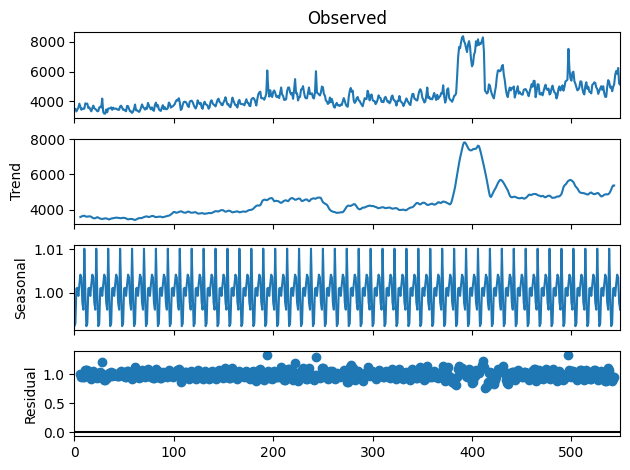

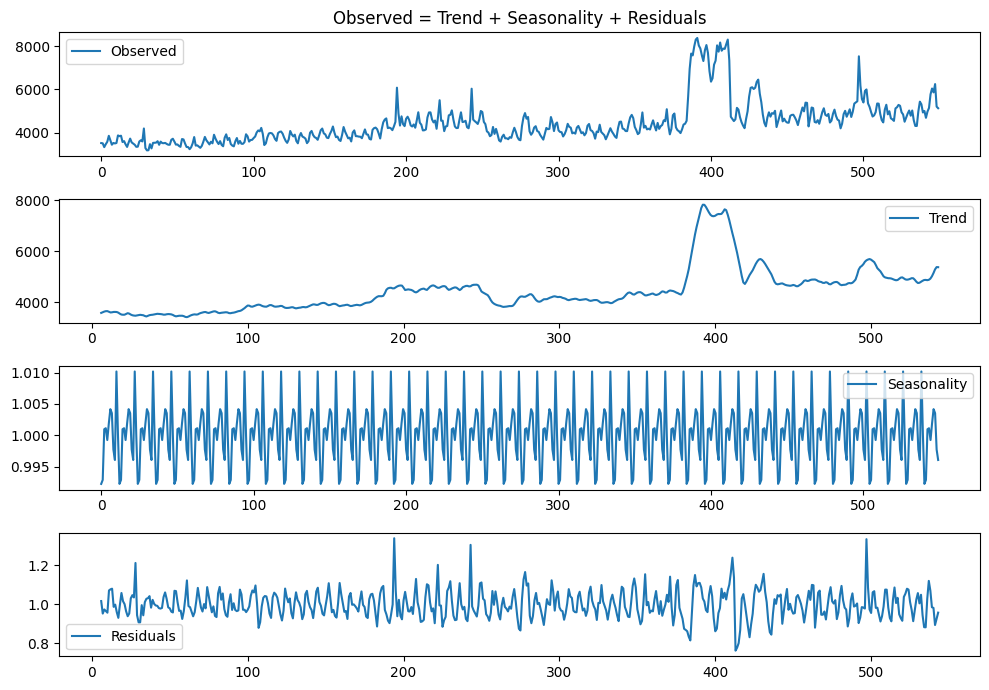

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(ts.values, model='multiplicative',period=12)
decomposition.plot()
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(10,7))
plt.subplot(411)
plt.title('Observed = Trend + Seasonality + Residuals')
plt.plot(ts.values,label='Observed')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


In [ ]:
ts_decompose=pd.DataFrame(residual).fillna(0)[0].values
df_test(ts_decompose)

ADF Stastistic: -0.119070
p-value: 0.947506



We can see that aur series is now stationary, we can also try diffrencing to see what results we can get.

**2. Remove trend and seasonality with differencing**

<Axes: xlabel='index'>

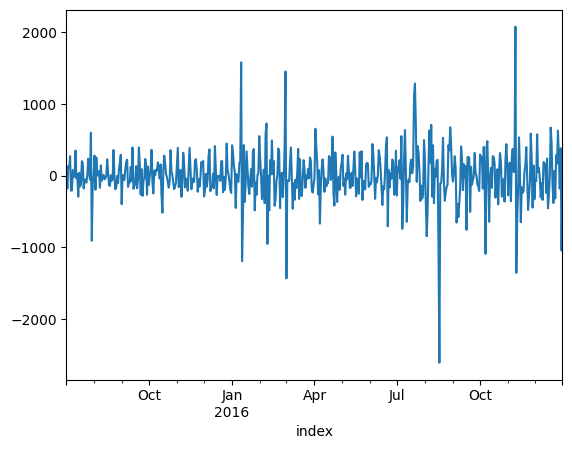

In [ ]:
ts.diff(1).dropna().plot()

**Plot the autocorreltaion and partial auto correlation functions**

Plotting the graphs and getting the p,q,d values for arima

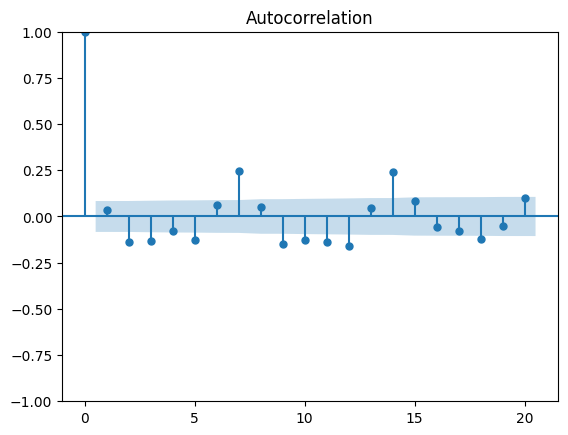

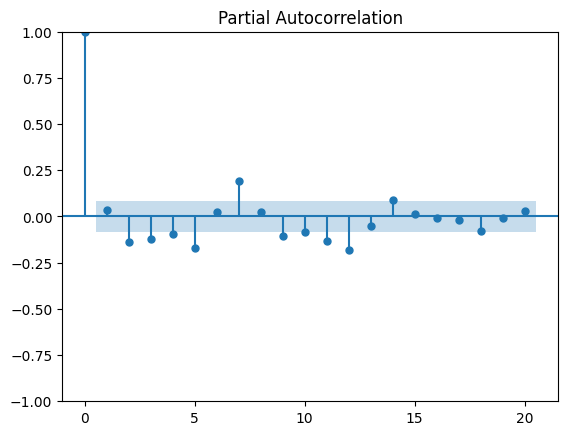

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
acf=plot_acf(ts.diff(1).dropna(),lags=20)
pacf=plot_pacf(ts.diff(1).dropna(),lags=20)

In [ ]:
Dickey_Fuller_test(ts.diff(1).dropna())

Time Series is Stationary
P_value is:  5.292474635436075e-13


* After 1 differentiation, time series becomes stationary.
* Thus for ARIMA models , we can set d = 1

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def performance(actual, predicted):
  print("MAE: {}".format(mean_absolute_error(actual, predicted)))
  print("MSE: {}".format(mean_squared_error(actual, predicted)))
  print("RMSE: {}".format((mean_squared_error(actual, predicted)**0.5)))
  print("MAPE: {}".format(mean_absolute_percentage_error(actual, predicted)*100))

**Forecasting :**

<Axes: xlabel='index'>

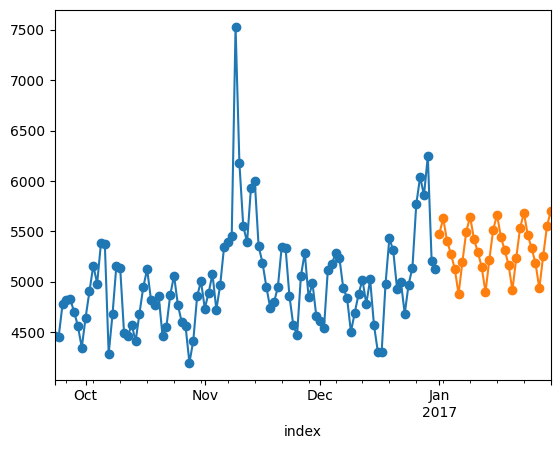

In [ ]:
TS_English =ts.copy()
TS_English.index.freq = 'D'
model = sm.tsa.ExponentialSmoothing(TS_English, seasonal='add',trend="add")
model = model.fit()
 # default values
# of smoothing_level, seasonal_
# and trend smoothing

TS_English.tail(100).plot(style='-o', label='actual')
model.forecast(30).plot(style='-o', label='predicted')

MAE: 394.9761340981992
MSE: 317362.59685695666
RMSE: 563.3494447116786
MAPE: 7.306826642310248


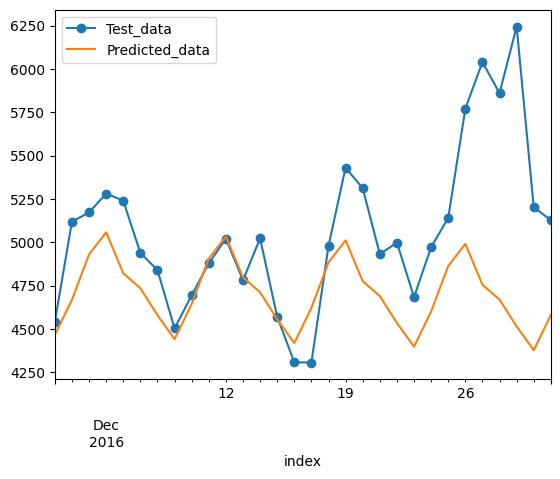

In [ ]:
X_train = TS_English.loc[TS_English.index < TS_English.index[-30] ].copy()
X_test = TS_English.loc[TS_English.index >= TS_English.index[-30] ].copy()
import warnings # supress warnings
warnings.filterwarnings('ignore')
model = sm.tsa.ExponentialSmoothing(X_train,
 trend="add",
damped_trend="add",
seasonal="add")
model = model.fit(smoothing_level=None, # alpha
 smoothing_trend=None, # beta
 smoothing_seasonal=None) # gama)
# X_test.plot()
Pred = model.forecast(steps=30)
performance(X_test,Pred)
X_test.plot(style="-o",label ="Test_data")
Pred.plot(label="Predicted_data")
plt.legend()
plt.show()

ARIMA :
Autoregressive Integrated Moving Average (ARIMA) model, and extensions
This model is the basic interface for ARIMA-type models, including those with exogenous
regressors and those with seasonal components. The most general form of the model is
SARIMAX(p, d, q)x(P, D, Q, s). It also allows all specialized cases, including autoregressive
models: AR(p)
moving average models: MA(q)
mixed autoregressive moving average models: ARMA(p, q)
integration models: ARIMA(p, d, q)
seasonal models: SARIMA(P, D, Q, s)
regression with errors that follow one of the above ARIMA-type models

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
TS = TS_English.copy(deep=True)

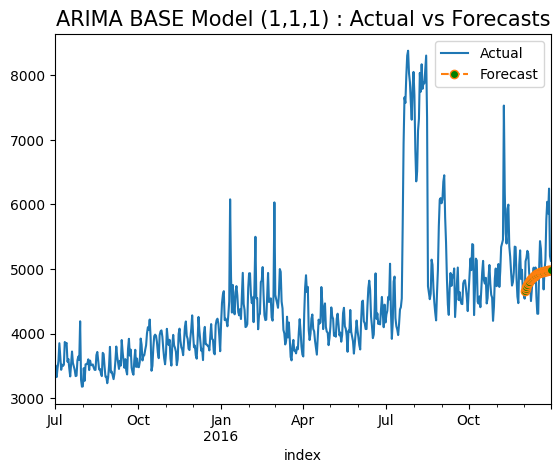


MAPE of Model : 0.06585
RMSE of Model : 472.186


In [ ]:
n_forecast = 30
model = ARIMA(TS[:-n_forecast],
 order = (1,1,1))
model = model.fit()
predicted = model.forecast(steps= n_forecast, alpha = 0.05)
TS.plot(label = 'Actual')
predicted.plot(label = 'Forecast', linestyle='dashed', marker='o',markerfacecolor='g')
plt.legend(loc="upper right")
plt.title('ARIMA BASE Model (1,1,1) : Actual vs Forecasts', fontsize = 15)
plt.show()
#Calculating MAPE & RMSE
actuals = TS.values[-n_forecast:]
errors = TS.values[-n_forecast:] - predicted.values
mape = np.mean(np.abs(errors)/ np.abs(actuals))
rmse = np.sqrt(np.mean(errors**2))
print()
print(f'MAPE of Model : {np.round(mape,5)}')
print(f'RMSE of Model : {np.round(rmse,3)}')

we can see that the model does not perform very well for multistep out sample data

from the decomposition we can see that there is a weekly seasonality and still some spikes in the residual, that may be because of some external factors, which we can take into account by using them as our exogenous variable

**SARIMAX model :**

Downloading exogenous value

In [ ]:
ex_df = pd.read_csv('Exog_Campaign_eng')
ex_df.head()

,Exog
0,0
1,0
2,0
3,0
4,0


In [ ]:
exog=ex_df['Exog'].to_numpy()

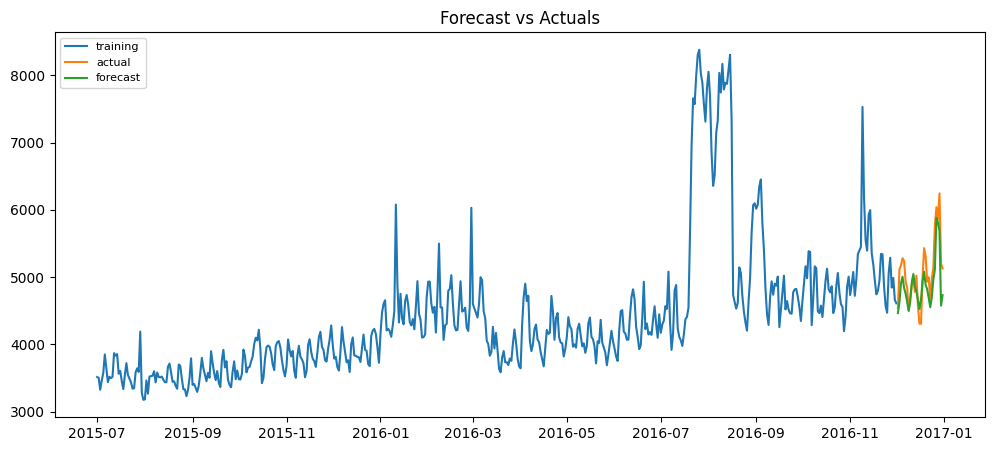

In [ ]:
import statsmodels.api as sm
train=ts[:520]
test=ts[520:]
model=sm.tsa.statespace.SARIMAX(train,order=(4, 1, 3),seasonal_order=(1,1,1,7),exog=exog[:520])
results=model.fit()

fc=results.forecast(30,dynamic=True,exog=pd.DataFrame(exog[520:]))

# Make as pandas series
fc_series = pd.Series(fc)
# Plot
train.index=train.index.astype('datetime64[ns]')
test.index=test.index.astype('datetime64[ns]')
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')

plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
#Calculating MAPE & RMSE
actuals = train.values[-n_forecast:]
errors = train.values[-n_forecast:] - predicted.values
mape = np.mean(np.abs(errors)/ np.abs(actuals))
rmse = np.sqrt(np.mean(errors**2))
print()
print(f'MAPE of Model : {np.round(mape,5)}')
print(f'RMSE of Model : {np.round(rmse,3)}')

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarimax_model(time_series, n, p=0, d=0, q=0, P=0, D=0, Q=0, s=0, exog = []):
    model = SARIMAX(time_series[:-n], \
    order =(p,d,q),
    seasonal_order=(P, D, Q, s),
    exog = exog[:-n],
    initialization='approximate_diffuse')
    model_fit = model.fit()

    #Creating forecast for last n-values
    model_forecast = model_fit.forecast(n, dynamic = True, exog = pd.DataFrame(exog[-n:]))

    #plotting Actual & Forecasted values

    plt.figure(figsize = (20,8))
    time_series[-60:].plot(label = 'Actual')
    model_forecast.plot(label = 'Forecast', color = 'red')
    plt.legend(loc="upper right")
    plt.title(f'SARIMAX Model ({p},{d},{q}) ({P},{D},{Q},{s}) : Actual vs Forecasts')
    plt.show()

    #Calculating MAPE & RMSE
    actuals = time_series.values[-n:]
    errors = time_series.values[-n:] - model_forecast.values
    mape = np.mean(np.abs(errors)/ np.abs(actuals))
    rmse = np.sqrt(np.mean(errors**2))
    print()
    print(f'MAPE of Model : {np.round(mape,5)}')
    print(f'RMSE of Model : {np.round(rmse,3)}')
    plt.show()

    #Calculating MAPE & RMSE
    actuals = time_series.values[-n:]
    errors = time_series.values[-n:] - model_forecast.values
    mape = np.mean(np.abs(errors)/ np.abs(actuals))
    rmse = np.sqrt(np.mean(errors**2))
    print()
    print(f'MAPE of Model : {np.round(mape,5)}')
    print(f'RMSE of Model : {np.round(rmse,3)}')

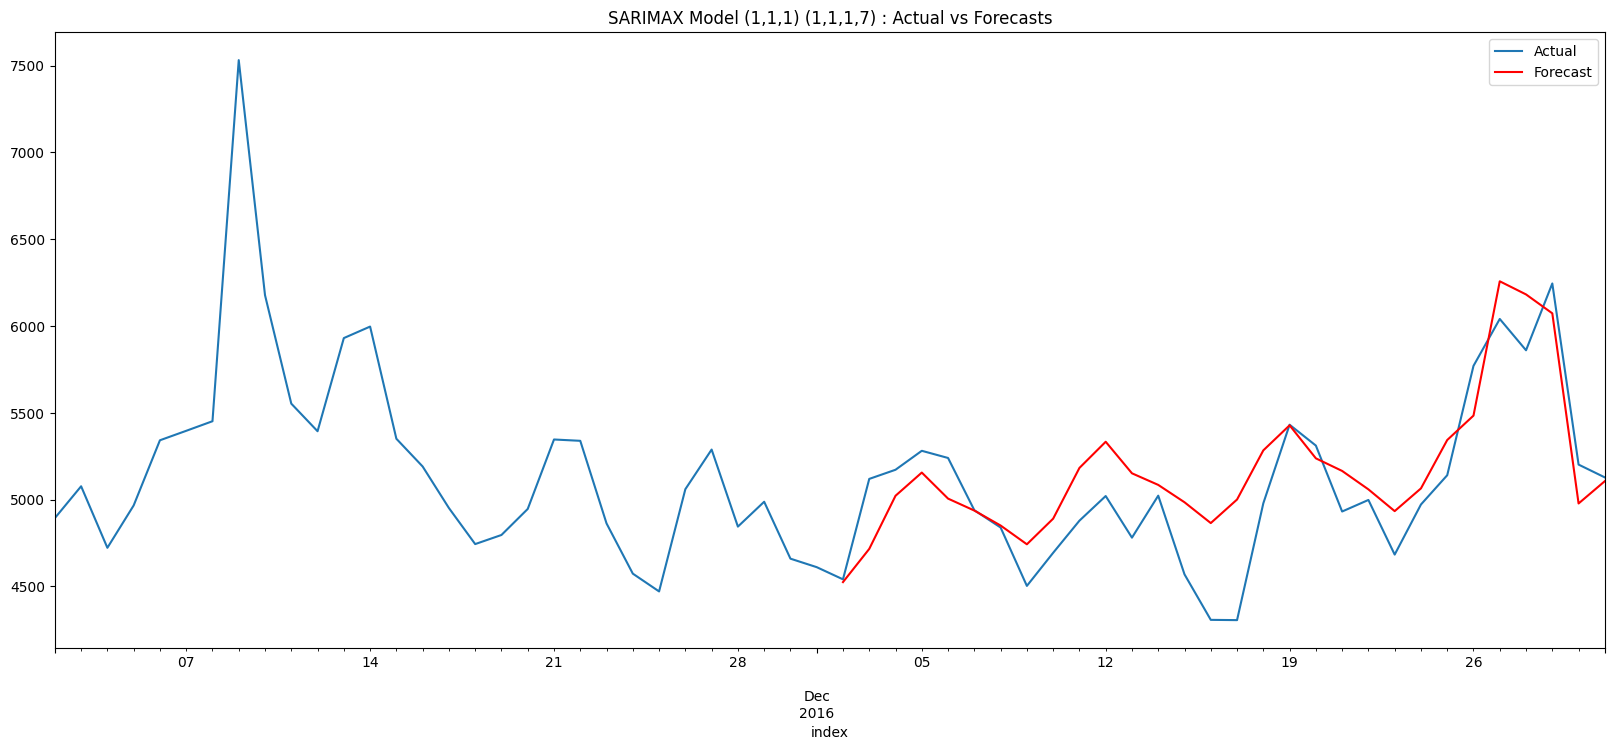


MAPE of Model : 0.04453
RMSE of Model : 272.731

MAPE of Model : 0.04453
RMSE of Model : 272.731


In [ ]:

TS_English =ts.copy()
TS_English.index.freq = 'D'
test_size= 0.1
p,d,q, P,D,Q,s = 1,1,1,1,1,1,7
n = 30
sarimax_model(TS_English, n, p=p, d=d, q=q, P=P, D=D, Q=Q, s=s, exog = exog)

Regression model

In [ ]:
ts_df=ts.to_frame()
ts_df.head()

,en
index,
2015-07-01,3513.862203
2015-07-02,3502.511407
2015-07-03,3325.357889
2015-07-04,3462.054256
2015-07-05,3575.520035


In [ ]:
ts_df.reset_index(level=0, inplace=True)
ts_df['date']=pd.to_datetime(ts_df['index'])
ts_df.drop(['index'],axis=1,inplace=True)
ts_df.head()

,en,date
0,3513.862203,2015-07-01
1,3502.511407,2015-07-02
2,3325.357889,2015-07-03
3,3462.054256,2015-07-04
4,3575.520035,2015-07-05


In [ ]:
ts_df['day_of_week']=ts_df['date'].dt.day_name()
ts_df.head()

,en,date,day_of_week
0,3513.862203,2015-07-01,Wednesday
1,3502.511407,2015-07-02,Thursday
2,3325.357889,2015-07-03,Friday
3,3462.054256,2015-07-04,Saturday
4,3575.520035,2015-07-05,Sunday


In [ ]:
ts_df['exog']=ex_df['Exog']
ts_df['rolling_mean']=ts_df['en'].rolling(7).mean()

In [ ]:
ts_df=pd.get_dummies(ts_df, columns = ['day_of_week'])

In [ ]:
ts_df.head()

,en,date,exog,rolling_mean,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,3513.862203,2015-07-01,0,NaN,False,False,False,False,False,False,True
1,3502.511407,2015-07-02,0,NaN,False,False,False,False,True,False,False
2,3325.357889,2015-07-03,0,NaN,True,False,False,False,False,False,False
3,3462.054256,2015-07-04,0,NaN,False,False,True,False,False,False,False
4,3575.520035,2015-07-05,0,NaN,False,False,False,True,False,False,False


In [ ]:
ts_df['exog']=ex_df['Exog']
ts_df['rolling_mean']=ts_df['en'].rolling(7).mean()

In [ ]:
ts_df=ts_df.dropna()
ts_df.head()


,en,date,exog,rolling_mean,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
6,3643.523063,2015-07-07,0,3553.223554,False,False,False,False,False,True,False
7,3437.871080,2015-07-08,0,3542.367679,False,False,False,False,False,False,True
8,3517.459391,2015-07-09,0,3544.503105,False,False,False,False,True,False,False
9,3497.571594,2015-07-10,0,3569.105063,True,False,False,False,False,False,False
10,3517.054297,2015-07-11,0,3576.962212,False,False,True,False,False,False,False


In [ ]:
X=ts_df[['day_of_week_Friday',	'day_of_week_Monday',	'day_of_week_Saturday',	'day_of_week_Sunday',	'day_of_week_Thursday',	'day_of_week_Tuesday',	'day_of_week_Wednesday',	'exog',	'rolling_mean']].copy()
y=ts_df[['en']]

train_x = X[:-20]
test_x = X[-20:]

train_y = y[:-20]
test_y = y[-20:]


In [ ]:
from sklearn.linear_model import LinearRegression

# Train and pred
model = LinearRegression()
model.fit(train_x, train_y)
y_pred = (model.predict(test_x))


mape = np.mean(np.abs(y_pred - test_y.values)/np.abs(test_y.values))
print("mape:",mape)


mape: 0.04529072768892774


We can see here that aur mape is better than our arima model but worse than our sarimax model

Linear Regression Is Limited to Linear Relationships and in our case there is not a lot of linear relationship.
it would have been better to use a regression based model for forecasting if we can build some better features.
we have our series data and the exogenous variables, we add the day of week feature, other than that there are not a lot of features that we can build

In [ ]:

!pip install prophet

In [ ]:
ts_df['ds']=ts_df['date']
ts_df['y']=ts_df['en']

In [ ]:
df2=ts_df[['date','en','exog']].copy()
df2.columns = ['ds', 'y', 'exog']
df2.head()

,ds,y,exog
6,2015-07-07,3643.523063,0
7,2015-07-08,3437.871080,0
8,2015-07-09,3517.459391,0
9,2015-07-10,3497.571594,0
10,2015-07-11,3517.054297,0


In [ ]:
df2[:-20].info()

<class 'pandas.core.frame.DataFrame'>
Index: 524 entries, 6 to 529
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      524 non-null    datetime64[ns]
 1   y       524 non-null    float64       
 2   exog    524 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 16.4 KB


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvlzu4esl/eovtm3eu.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvlzu4esl/5nwrzxyg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=44012', 'data', 'file=/tmp/tmpvlzu4esl/eovtm3eu.json', 'init=/tmp/tmpvlzu4esl/5nwrzxyg.json', 'output', 'file=/tmp/tmpvlzu4esl/prophet_modelufjo__wu/prophet_model-20241226175623.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:56:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:56:24 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


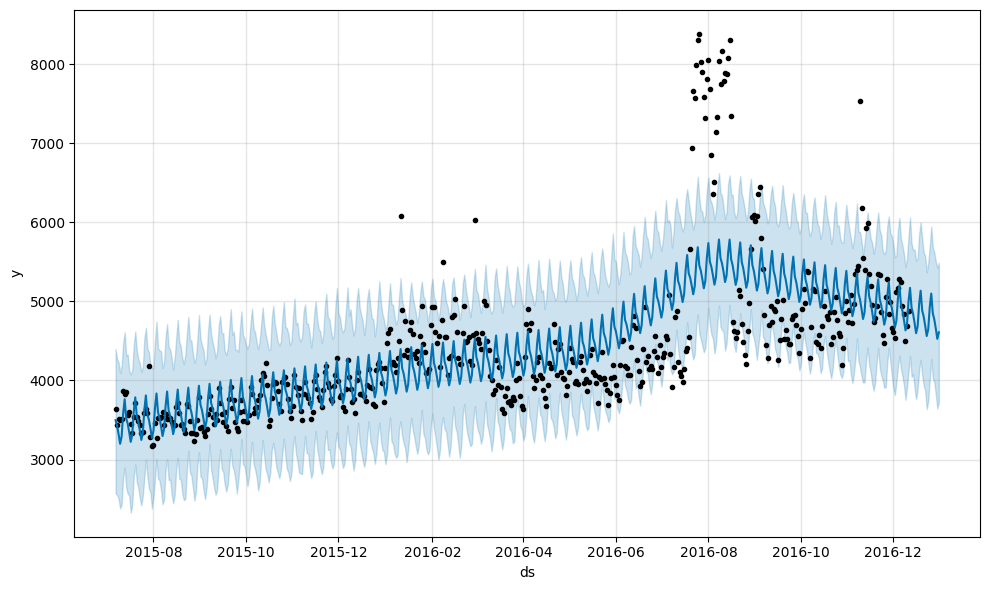

In [ ]:
from prophet import Prophet
m = Prophet(weekly_seasonality=True)
m.fit(df2[['ds', 'y']][:-20])
future = m.make_future_dataframe(periods=20,freq="D")
forecast = m.predict(future)
fig = m.plot(forecast)

prophet with exogenous

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvlzu4esl/t785ivcz.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvlzu4esl/jmys449p.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=43696', 'data', 'file=/tmp/tmpvlzu4esl/t785ivcz.json', 'init=/tmp/tmpvlzu4esl/jmys449p.json', 'output', 'file=/tmp/tmpvlzu4esl/prophet_modeluhjmt7t3/prophet_model-20241226175659.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:56:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:57:00 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


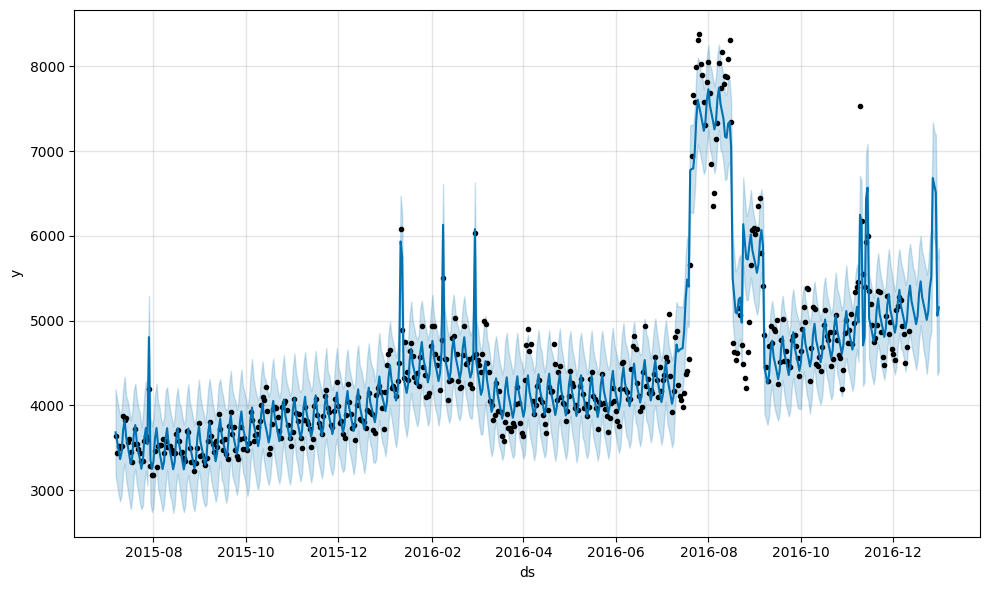

In [ ]:
model2=Prophet(interval_width=0.9, weekly_seasonality=True, changepoint_prior_scale=1)
model2.add_regressor('exog')
model2.fit(df2[:-20])
forecast2 = model2.predict(df2)
fig = model2.plot(forecast2)

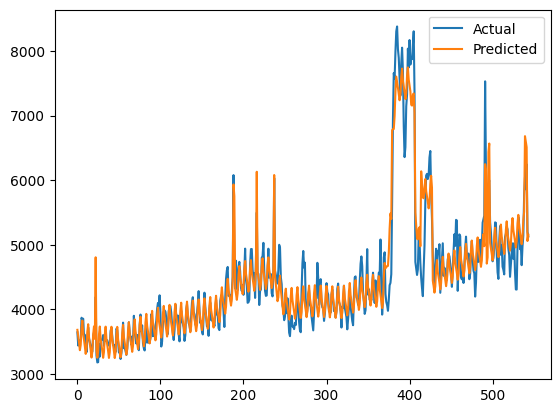

In [ ]:
y_true = df2['y'].values
y_pred = forecast2['yhat'].values

plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()

In [ ]:
mape = np.mean(np.abs(forecast2['yhat'][-20:] - df2['y'][-20:].values)/np.abs(df2['y'][-20:].values))
print("mape:",mape)

mape: 0.06399474265970848


Prophet does not perform well on non-stationary data because it is difficult to find the actual seasonality and trend of the data if the patterns are inconsistent.

Comparing the predicted views for different languages

In [ ]:
def grid_search(ts):
    v=[0,1,2,3]
    mape=100
    val=[0,0,0]
    for p in v:
        for d in v:
            for q in v:
                try:
                    model = ARIMA(ts[:-20], order=(p,d,q))
                    model_fit = model.fit(disp=-1)
                    fc, se, conf = model_fit.forecast(20, alpha=0.02)
                    x = np.mean(np.abs(fc - ts[-20:].values)/np.abs(ts[-20:].values))
                    if(x<mape):
                        mape=x
                        val=[p,d,q]

                except:
                    pass

    return(mape, val)

This functions works like a grid search for getting the best value of p,d,q by comparing the mape of all models that we create.

the values of p,d,q that give the least mape score are saved and returned

In [ ]:
def all_arima(train,test,val):
    model = ARIMA(train, order=(val[0], val[1], val[2]))
    fitted = model.fit()

  # Forecast
    forecast_results = fitted.get_forecast(steps=30, alpha=0.02)  # Get forecast results

    fc = forecast_results.predicted_mean  # Extract predicted mean
    se = forecast_results.se_mean  # Extract standard error of the mean
    conf = forecast_results.conf_int()

    fc_series = pd.Series(fc, index=test.index)

  # Plot
    plt.figure(figsize=(12,5), dpi=100)
    plt.plot(train, label='training')
    plt.plot(test, label='actual')
    plt.plot(fc_series, label='forecast')
    plt.title('Forecast vs Actuals')
    plt.legend(loc='upper left', fontsize=8)
    plt.show()
    mape = np.mean(np.abs(fc - test.values)/np.abs(test.values))
    rmse = np.mean((fc - test.values)**2)**.5
    print("mape:",mape)
    print("rsme:",rmse)
    return (fc)


language:  de
100 [0, 0, 0]


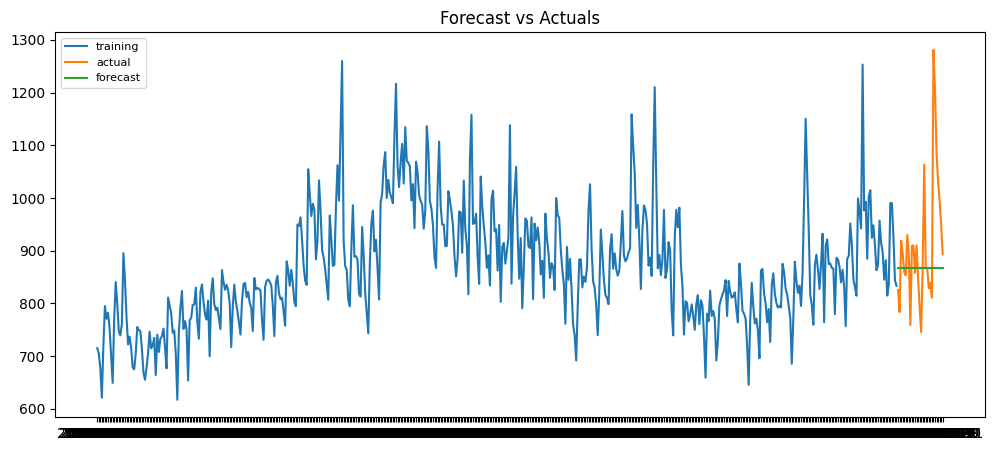

mape: 0.08307094918536781
rsme: 127.2386518264283
language:  en
100 [0, 0, 0]


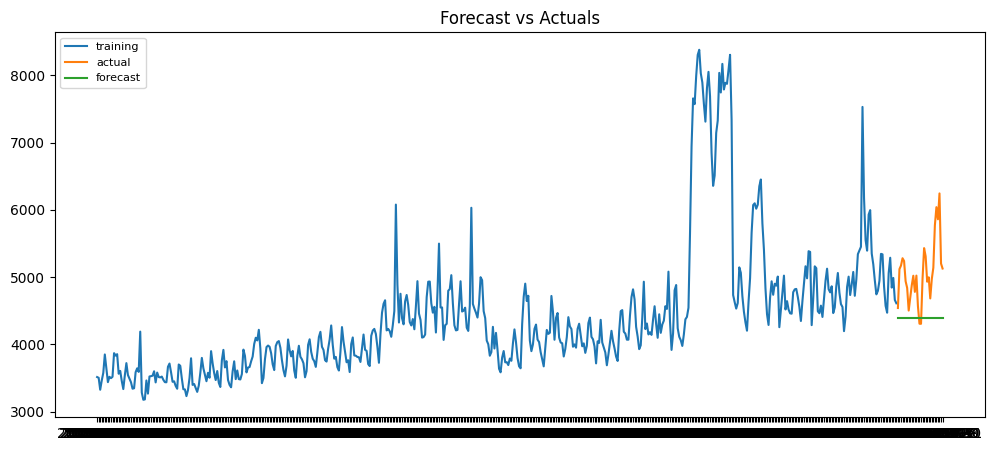

mape: 0.12808878080165195
rsme: 810.8337645801747
language:  es
100 [0, 0, 0]


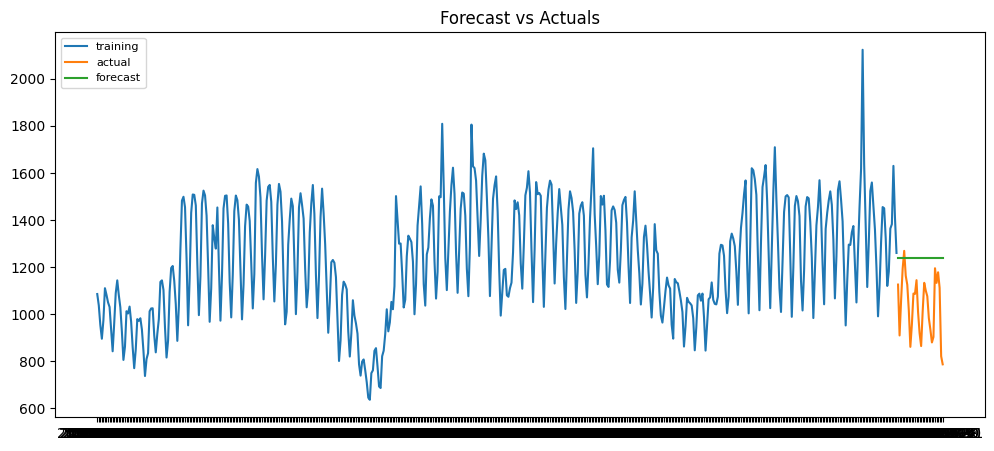

mape: 0.2155697522281242
rsme: 237.61924662383274
language:  fr
100 [0, 0, 0]


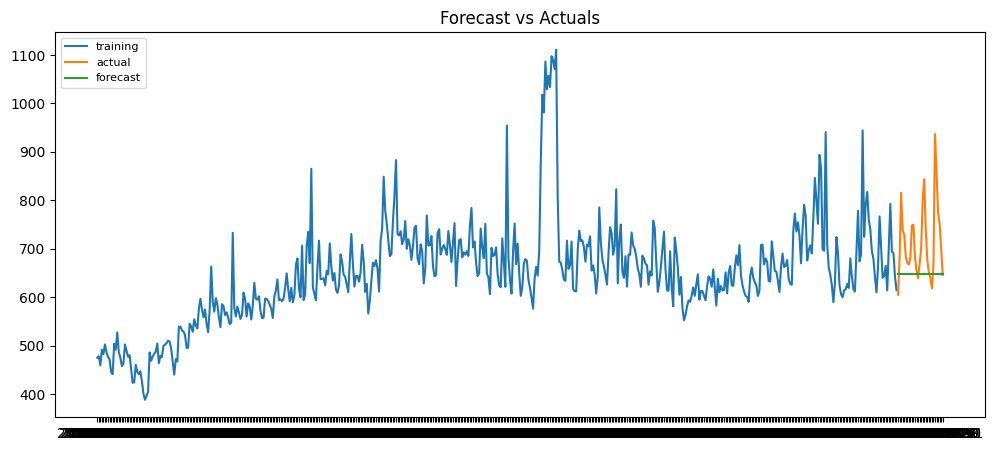

mape: 0.09317398611932173
rsme: 100.66094642309743
language:  ja
100 [0, 0, 0]


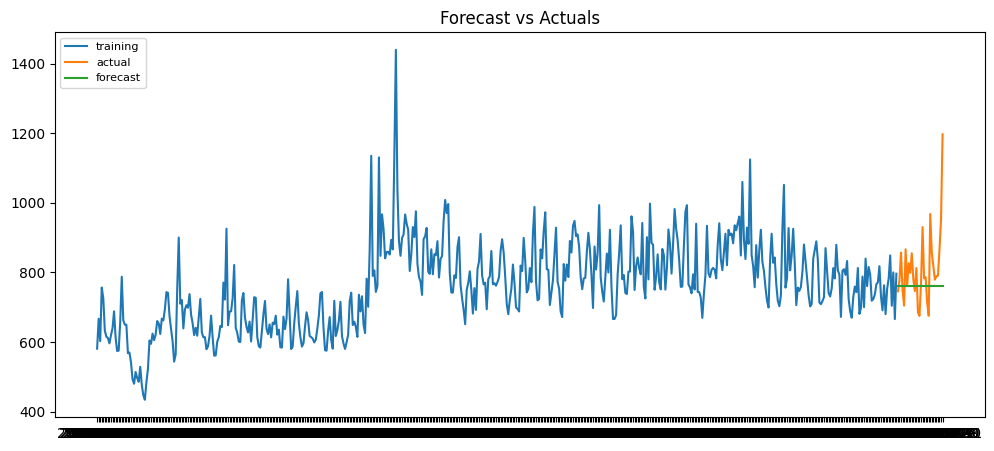

mape: 0.08645579347117241
rsme: 114.39444148974991
language:  no_lang
100 [0, 0, 0]


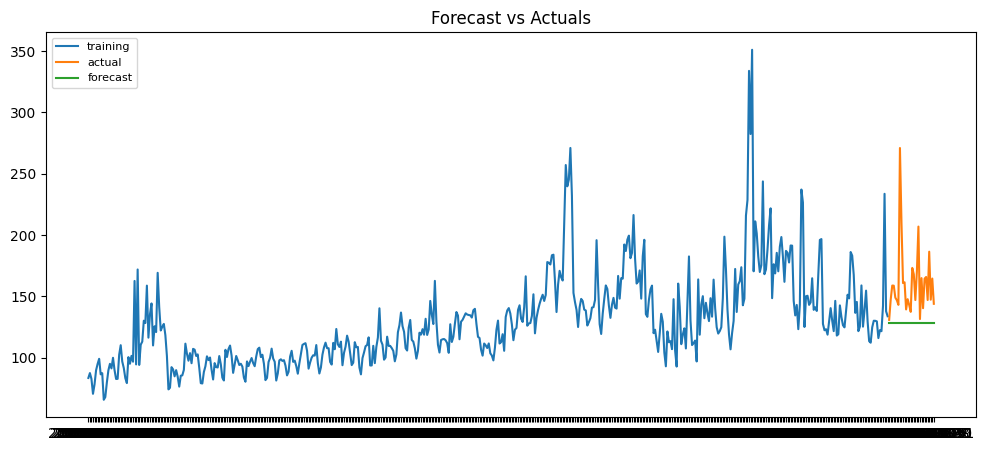

mape: 0.18340156125621132
rsme: 42.67603981484574
language:  ru
100 [0, 0, 0]


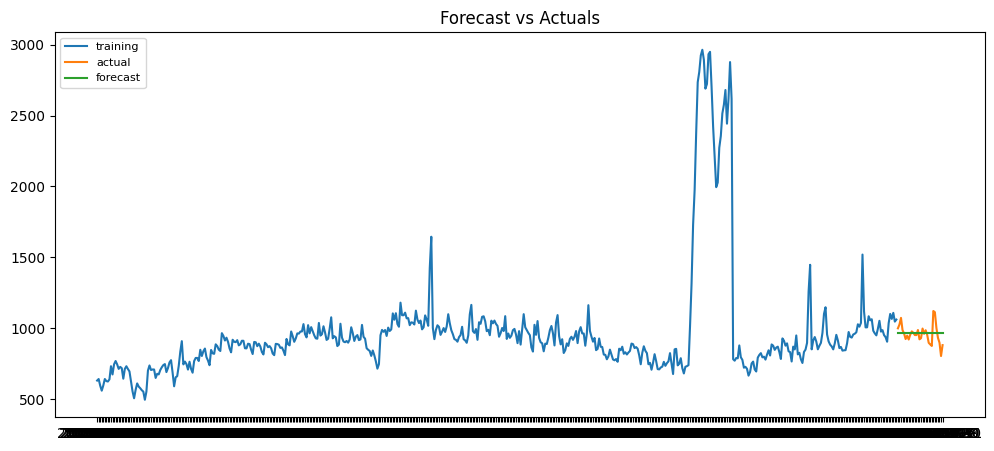

mape: 0.052784049083603984
rsme: 66.95328600105314
language:  zh
100 [0, 0, 0]


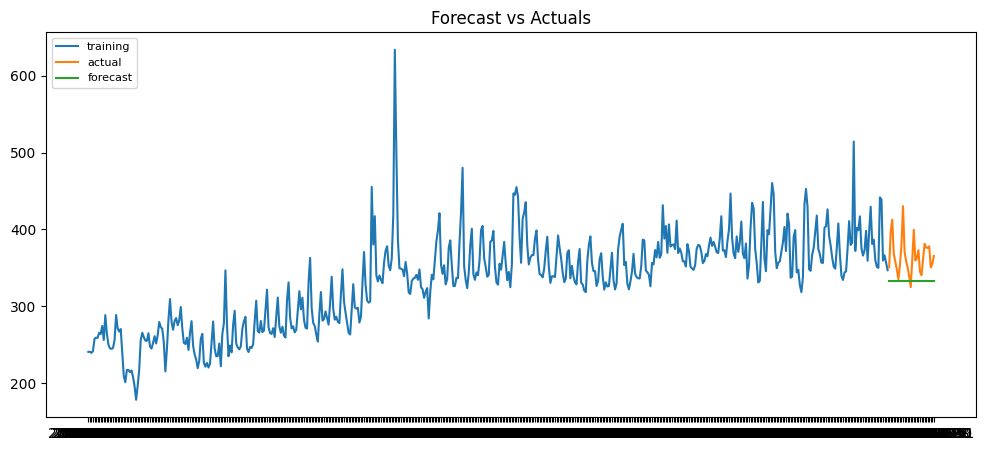

mape: 0.0871188174299172
rsme: 39.52329586271537


In [ ]:
import warnings
warnings.filterwarnings("ignore")
views_prediction={}
for c in df_language.columns:
    print("language: ",c)
    ts=(df_language[c])
    mape,val=grid_search(ts)
    print(mape,val)
    train = ts[:520]
    test = ts[520:]
    fc=all_arima(train,test,val)
    views_prediction[c]=fc


This function is what calls and drives all the other functions.

It first gets the data for a particular language.

checks stationarity.

Gets the optimal p,d,q values from grid search

uses that value to train the model, forecast and plot it

Insights:
Conclusions drawn from the data visuals:
There were 7 languages in all in the data.
The language with the most pages is English.
Three categories of access:
1. 51.2295 % of All-access
2. Mobile web 24.7748 percent
3. 23.9958 % on a desktop
Two points of access:
a. The language with the most pages is English (74.932526%); Agents (74.932526%); Spider
(24.067474%).
b. The English page ought to run the most advertising possible.
What distinguishes arima from sarima and sarimax:
1. Arima:
A statistical model for time series data called ARIMA (AutoRegressive Integrated Moving
Average) takes into consideration both moving average and autoregression, which both
involve using the residuals of previous predictions to predict future values.
It is a versatile technique that works with both univariate and multivariate time series to
model non-stationary time series data.
The notations ARIMA(p, d, q) are used to represent ARIMA models, where p represents the
autoregression component's order, d represents the differencing order that stabilizes the
time series, and q represents the moving average component's order.
1. Sarima:
An adaptation of ARIMA that takes into consideration time series data's non-stationarity
and seasonality is called SARIMA (Seasonal AutoRegressive Integrated Moving Average).
Recurring patterns in data across predetermined time intervals—daily, weekly, or annual—
are referred to as seasonality. SARIMA models are identified by the notations SARIMA(p, d,
q)(P, D, Q, S), where P is the order of the seasonal moving average component, Q is the
order of the seasonal autoregression component, S is the number of seasons in the data,
and p, d, and q are the same as in ARIMA models.
1. Sarimax:
An modification of SARIMA that permits the use of exogenous variables—that is, factors not
included in the time series data—in the modeling process is called SARIMAX (Seasonal
AutoRegressive Integrated Moving Average with exogenous regressors).
SARIMAX models can produce more accurate forecasts and are helpful when the time series
data is impacted by variables outside of the time series data.
The notations SARIMAX(p, d, q)(P, D, Q, S)x are used to describe SARIMAX models. In these
notations, p, d, q, P, D, Q, and S are the same as in SARIMA models, and x is the number of
exogenous variables that are included in the model.


Recommendations :
To ascertain whether the time series is stationary, do an enhanced Dickey-Fuller test.
Fit an ARMA model if the time series is stationary. If it is non-stationary, find out what d is.
Plot the data's autocorrelation and partial autocorrelation graphs once stationarity has been
attained.
Since the cut-off point in the partial autocorrelation graph (PACF) equals p, plot the PACF to
find the value of p.
Plot the autocorrelation graph (ACF) to find q, since q is the value of the ACF's cut-off point.

In [ ]:






















































































######